# Chapter 6 notebook — Real-time camera inference (frame-level)

Walks through `docs/09_realtime_camera_ai.md` but in a way that runs in a notebook (no GUI window). We process a video file frame-by-frame, run inference on each frame, and display sample annotated frames inline.

For the *live* webcam version, use `python src/inference/camera_loop.py` from a terminal.

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort

from src.inference.camera_loop import preprocess_frame, draw_overlay, _CLASSES, softmax

ONNX = Path('../experiments/exported_models/mobilenet_v3_small.onnx')
VIDEO = Path('../datasets/sample_video.mp4')
assert ONNX.exists() and VIDEO.exists(), 'run Chapter 2 notebook (exports) and the camera_loop smoke test first'

sess = ort.InferenceSession(ONNX.as_posix(), providers=['CPUExecutionProvider'])
in_name = sess.get_inputs()[0].name

## 1. Open the video and inspect properties

In [2]:
cap = cv2.VideoCapture(VIDEO.as_posix())
props = {
    'fps':        cap.get(cv2.CAP_PROP_FPS),
    'width':      int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
    'height':     int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    'frame_count': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
}
print(props)

{'fps': 25.0, 'width': 640, 'height': 480, 'frame_count': 60}


## 2. Run the loop and collect per-frame timings

We collect:
- `cap_ms` — time spent in `cap.read()` per frame.
- `prep_ms` — time spent in preprocessing.
- `inf_ms` — time spent in inference.
- `post_ms` — time spent in postprocessing + overlay.

Adding them up gives you the per-frame budget.

In [3]:
cap_ms, prep_ms, inf_ms, post_ms = [], [], [], []
annotated_frames = []

for i in range(60):
    t0 = time.perf_counter(); ok, frame = cap.read(); cap_ms.append((time.perf_counter() - t0) * 1000)
    if not ok:
        break
    t0 = time.perf_counter(); x = preprocess_frame(frame); prep_ms.append((time.perf_counter() - t0) * 1000)
    t0 = time.perf_counter(); (logits,) = sess.run(None, {in_name: x}); inf_ms.append((time.perf_counter() - t0) * 1000)
    t0 = time.perf_counter()
    probs = softmax(logits, axis=-1)[0]
    idx = int(probs.argmax())
    label = f'{_CLASSES[idx]} ({probs[idx] * 100:.1f}%)'
    fps_now = 1000.0 / max(1e-3, inf_ms[-1] + prep_ms[-1] + cap_ms[-1] + 1e-3)
    draw_overlay(frame, label, fps_now, inf_ms[-1])
    post_ms.append((time.perf_counter() - t0) * 1000)
    if i in (0, 20, 40, 59):
        annotated_frames.append(frame.copy())

cap.release()
for name, lst in [('cap', cap_ms), ('prep', prep_ms), ('inf', inf_ms), ('post', post_ms)]:
    a = np.array(lst)
    print(f'{name:5s} mean={a.mean():6.2f} ms  P95={np.percentile(a, 95):6.2f} ms')

total = np.array(cap_ms) + np.array(prep_ms) + np.array(inf_ms) + np.array(post_ms)
print(f'\nend-to-end per-frame mean={total.mean():.2f} ms  → ~{1000.0/total.mean():.1f} FPS')

cap   mean=  0.41 ms  P95=  0.92 ms
prep  mean=  2.59 ms  P95=  3.11 ms
inf   mean=  1.54 ms  P95=  2.10 ms
post  mean=  0.51 ms  P95=  0.78 ms

end-to-end per-frame mean=5.04 ms  → ~198.3 FPS


## 3. Visualize the latency breakdown

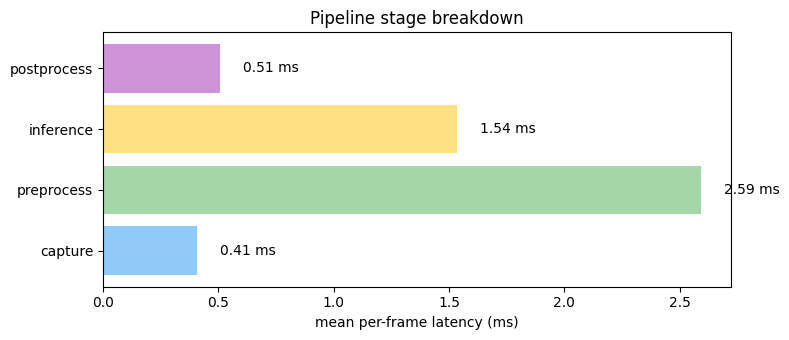

In [4]:
labels = ['capture', 'preprocess', 'inference', 'postprocess']
means = [np.mean(cap_ms), np.mean(prep_ms), np.mean(inf_ms), np.mean(post_ms)]

plt.figure(figsize=(8, 3.5))
plt.barh(labels, means, color=['#90caf9', '#a5d6a7', '#ffe082', '#ce93d8'])
for i, v in enumerate(means):
    plt.text(v + 0.1, i, f'{v:.2f} ms', va='center')
plt.xlabel('mean per-frame latency (ms)')
plt.title('Pipeline stage breakdown')
plt.tight_layout()
plt.show()

## 4. Sample annotated frames

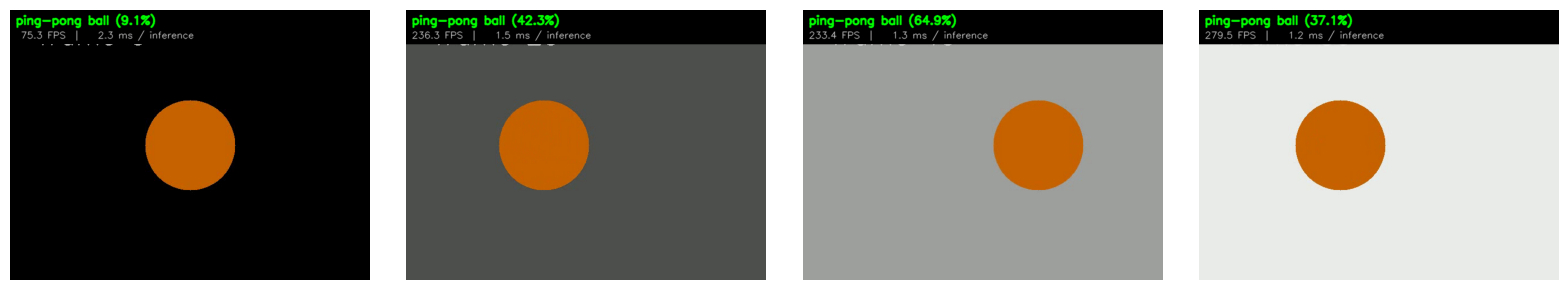

In [5]:
fig, axes = plt.subplots(1, len(annotated_frames), figsize=(4 * len(annotated_frames), 3))
if len(annotated_frames) == 1:
    axes = [axes]
for ax, frame in zip(axes, annotated_frames):
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout()
plt.show()

## Take-aways

1. The latency breakdown tells you which stage to optimize first. Often it is NOT inference.
2. On a USB webcam, `cap.read()` is usually the dominant cost (~30 ms per frame).
3. Preprocessing should be in NumPy / OpenCV, not PIL, when running every frame.
4. Drawing overlay + `imshow` adds another few ms — measure it.
5. The reference script `src/inference/camera_loop.py` runs the same pipeline live on a webcam, with all the optimizations from the chapter doc.